# Impact Assessment — Road Network and Population Exposure (Lokoja, October 2022 Floods)

*Sentinel-1/Sentinel-2 change detection combined with the OpenStreetMap road network and WorldPop population data, Google Earth Engine*

`Index_Analysis.ipynb` establishes and statistically validates the flood-detection thresholds for the October 2022 Niger–Benue floods at Lokoja (MNDWI > 0 for Sentinel-2, VH < −19 dB for Sentinel-1). This notebook reuses the same Region of Interest and the same thresholds, and applies them to the two remaining links of the impact-assessment chain that the index notebook does not cover: **infrastructure** (how much of the road network is impassable or uncertain, and which localities risk becoming cut off) and **population** (how many people are located inside the mapped flood extent, and where). It follows the methodological chains described in *"Intégration du réseau routier OSM dans une analyse d'impact de catastrophe"* and *"Intégration d'une couche de population dans une analyse d'impact de catastrophe."*

# 0. Setup

In [1]:
# pip install earthengine-api geemap osmnx networkx

import ee
import geemap
ee.Authenticate()
ee.Initialize(project='festive-oxide-485716-b0')
print("Earth Engine test :", ee.String("OK").getInfo())

Earth Engine test : OK


In [2]:
import os

# Same shared output directory as Index_Analysis.ipynb (Appendix/outputs), so every
# figure/table this notebook exports lands alongside the index-analysis outputs.
OUT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'outputs'))
os.makedirs(OUT_DIR, exist_ok=True)

def save_figure(fig, filename, dpi=300):
    """Save a matplotlib figure to OUT_DIR as a PNG."""
    path = os.path.join(OUT_DIR, filename)
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    print(f"[export] Figure -> {path}")
    return path

def save_table(df, filename, index=True):
    """Save a DataFrame to OUT_DIR as a CSV."""
    path = os.path.join(OUT_DIR, filename)
    df.to_csv(path, index=index)
    print(f"[export] Table  -> {path}")
    return path

print(f"All figures and tables produced by this notebook will be exported to: {OUT_DIR}")

All figures and tables produced by this notebook will be exported to: /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs


In [3]:
import osmnx as ox
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

ox.settings.timeout = 300  # a ~90x90 km drivable-network Overpass query can take a while

print("osmnx", ox.__version__, "| networkx", nx.__version__, "| geopandas", gpd.__version__)

osmnx 2.1.0 | networkx 3.4.2 | geopandas 1.1.2


# 1. Study Framing

## 1.1 Study area and event window

We reuse, unchanged, the ROI and dates defined in `Index_Analysis.ipynb`: a rectangle around Lokoja, Nigeria, and the same pre-flood (July–August 2022) / flood (late September–October 2022) windows used there. Keeping these identical is what makes the road and population impact figures below directly comparable to the flood-extent figures already produced in the index notebook.

In [4]:
# Same ROI as Index_Analysis.ipynb -- a rectangle around Lokoja, Nigeria
Map = geemap.Map(center=[7.80, 6.73], zoom=9)
center_point = ee.Geometry.Point([6.73, 7.80])
roi = ee.Geometry.Rectangle([6.3, 7.4, 7.1, 8.2])

Map.addLayer(roi, {'color': 'red'}, 'Lokoja ROI', True, 0.4)
Map

Map(center=[7.8, 6.73], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

In [5]:
# Same event windows as Index_Analysis.ipynb
pre_flood_start = '2022-07-01'
pre_flood_end   = '2022-08-31'

flood_start = '2022-09-25'
flood_end   = '2022-10-31'

## 1.2 Operational objectives

Following §1.3 of the road-network methodology, "impact" is broken down into four concrete, measurable outputs:

- the surface extent of the flood (already mapped in `Index_Analysis.ipynb`);
- the length and share of the road network rendered impassable or uncertain;
- the localities at risk of losing road connectivity to central Lokoja;
- the population, and its distribution across administrative units, located inside the mapped flood extent.

Sections 4 and 5 below address the last three points in turn.

# 2. Data Sources

| Source | Role | Resolution | Vintage / frequency |
|---|---|---|---|
| Sentinel-1 GRD (`COPERNICUS/S1_GRD`) | All-weather change detection (flood) | 10 m | 6–12 days |
| Sentinel-2 SR (`COPERNICUS/S2_SR_HARMONIZED`) | Optical water index (MNDWI) | 10–20 m | ~5 days, cloud-permitting |
| OSM road network (via OSMnx / Overpass API) | Infrastructure exposed to the flood | vector | continuously updated |
| WorldPop (`WorldPop/GP/100m/pop`) | Population exposed to the flood | ~100 m | annual, 2000–2021 |
| FAO GAUL level 2 (`FAO/GAUL/2015/level2`) | Administrative units for zonal statistics (LGA level) | vector | 2015 |

The road network is retrieved directly through the Python `osmnx` package rather than imported as a pre-staged GEE table asset — §2.3 of the road methodology lists an Overpass API query as one of the two acquisition routes, and `osmnx` is exactly that: a thin, reproducible wrapper around Overpass. The resulting GeoDataFrame is converted to an `ee.FeatureCollection` in §4.1 below.

# 3. Flood Change-Detection Recap

This section reproduces, in condensed form, the Sentinel-1/Sentinel-2 flood masks validated in `Index_Analysis.ipynb` (thresholds calibrated and statistically checked there: MNDWI > 0, VH < −19 dB), so that this notebook is runnable on its own. One refinement is applied to Sentinel-1: the methodology (§3.1) flags fixing a single `orbitProperties_pass` between the pre- and post-event composites as indispensable, since a change of viewing geometry between the two dates otherwise produces false changes. `Index_Analysis.ipynb` does not fix this; it is added here.

In [6]:
# Sentinel-2 -- cloud masking via Cloud Score+ (same approach as Index_Analysis.ipynb)
s2_collection = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED").filterBounds(roi)
cs_plus = ee.ImageCollection("GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED").filterBounds(roi)
s2_linked = s2_collection.linkCollection(cs_plus, ['cs_cdf'])

def mask_clouds_csplus(image):
    clear_pixel_mask = image.select('cs_cdf').gte(0.6)
    return image.updateMask(clear_pixel_mask)

pre_flood_img = s2_linked.filterDate(pre_flood_start, pre_flood_end).map(mask_clouds_csplus).median().clip(roi)
flood_img     = s2_linked.filterDate(flood_start, flood_end).map(mask_clouds_csplus).median().clip(roi)

mndwi_pre   = pre_flood_img.normalizedDifference(['B3', 'B11']).rename('MNDWI')
mndwi_flood = flood_img.normalizedDifference(['B3', 'B11']).rename('MNDWI')

water_pre_mndwi    = mndwi_pre.gt(0)
water_flood_mndwi  = mndwi_flood.gt(0)
flooded_area_mndwi = water_flood_mndwi.subtract(water_pre_mndwi).gt(0)

In [7]:
# Sentinel-1 -- fix a single orbit pass shared by both periods (methodology §3.1)
s1_all = ee.ImageCollection('COPERNICUS/S1_GRD') \
    .filterBounds(roi) \
    .filter(ee.Filter.eq('instrumentMode', 'IW')) \
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))

passes_pre   = s1_all.filterDate(pre_flood_start, pre_flood_end).aggregate_array('orbitProperties_pass').distinct().getInfo()
passes_flood = s1_all.filterDate(flood_start, flood_end).aggregate_array('orbitProperties_pass').distinct().getInfo()
common_passes = sorted(set(passes_pre) & set(passes_flood))
print(f"Orbit passes available -- pre-flood: {passes_pre}, flood: {passes_flood}")
assert common_passes, "No orbit pass is shared by both windows -- widen the date windows."

orbit_pass = common_passes[0]
print(f"Using orbit pass '{orbit_pass}' for both periods.")

s1_collection = s1_all.filter(ee.Filter.eq('orbitProperties_pass', orbit_pass)).select('VH')

Orbit passes available -- pre-flood: ['ASCENDING'], flood: ['ASCENDING']
Using orbit pass 'ASCENDING' for both periods.


In [8]:
s1_pre_flood = s1_collection.filterDate(pre_flood_start, pre_flood_end).median() \
    .focal_median(50, 'circle', 'meters').clip(roi)
s1_flood = s1_collection.filterDate(flood_start, flood_end).median() \
    .focal_median(50, 'circle', 'meters').clip(roi)

s1_water_threshold = -19
s1_water_pre    = s1_pre_flood.lt(s1_water_threshold)
s1_water_flood  = s1_flood.lt(s1_water_threshold)
s1_flooded_area = s1_water_flood.subtract(s1_water_pre).gt(0)

## 3.1 Fused change mask

Following §4.3 of the road methodology, the optical and radar masks are combined by union: a pixel counts as "affected" if either sensor flags it.

$$\text{change}(x) = \text{MNDWI\_flood}(x) \;\vee\; \text{SAR\_flood}(x)$$

Both masks are `unmask(0)`-ed (treated as "not flooded") before the union, rather than combined directly. Earth Engine's per-pixel logical `Or` otherwise masks the output wherever *either* input is masked — so a cloud gap in the Sentinel-2 composite (frequent in this rainy-season window, per `Index_Analysis.ipynb`'s own observability study) would silently blank the fused mask even where Sentinel-1 clearly shows flooding, which is exactly the opposite of using SAR to fill optical gaps (§4.3's stated purpose). Unmasking first means a real detection from either sensor survives the other sensor's data gaps.

This fused mask is the single input used by both the road-impact and population-impact analyses below.

In [9]:
change_mask = flooded_area_mndwi.unmask(0).Or(s1_flooded_area.unmask(0)).rename('change')

Map.addLayer(flooded_area_mndwi.selfMask(), {'palette': ['cyan']}, 'S2 MNDWI flood (recap)', False)
Map.addLayer(s1_flooded_area.selfMask(), {'palette': ['orange']}, 'S1 VH flood (recap)', False)
Map.addLayer(change_mask.selfMask(), {'palette': ['#d7263d']}, 'Fused change mask (S1 OR S2)')
Map

Map(center=[7.8, 6.73], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

In [10]:
def get_area_ha(mask_image, region, scale=30):
    area_img = mask_image.rename('m').multiply(ee.Image.pixelArea())
    stats = area_img.reduceRegion(reducer=ee.Reducer.sum(), geometry=region, scale=scale, maxPixels=1e10)
    return stats.getNumber('m').divide(10000).getInfo()

fused_ha = get_area_ha(change_mask, roi)
print(f"Fused change mask (S1 OR S2): {fused_ha:,.2f} ha -- see Index_Analysis.ipynb for the S1-only/S2-only "
      "breakdown and its statistical validation.")

Fused change mask (S1 OR S2): 57,113.15 ha -- see Index_Analysis.ipynb for the S1-only/S2-only breakdown and its statistical validation.


# 4. Road Network Impact (OSM)

## 4.1 Acquisition

The drivable road network inside the ROI is downloaded live via `osmnx` (Overpass API), following §2.3/§3.3 of the road methodology. `network_type='drive'` is kept broad (it also includes residential streets) because the full graph is needed for the connectivity check in §4.6 — by default `osmnx` also keeps only the largest connected component of the *mapped* network, so §4.6 measures fragmentation introduced by the flood, not pre-existing OSM digitization gaps. The formal flood-impact classification in §4.2–§4.4, however, is restricted to the structuring classes the methodology recommends (`motorway`, `trunk`, `primary`, `secondary`, `tertiary`, and their `_link` variants) — both to match the methodology's own scope and to keep the `.getInfo()` payloads well under Earth Engine's 5,000-element limit (the full drivable network over this ROI has on the order of 27,000 edges; the structuring subset has on the order of 2,700).

In [11]:
west, south, east, north = 6.3, 7.4, 7.1, 8.2  # matches the `roi` rectangle above

print("Downloading the drivable road network from OpenStreetMap (Overpass API)...")
G_drive = ox.graph_from_bbox((west, south, east, north), network_type='drive', simplify=True)
edges = ox.graph_to_gdfs(G_drive, nodes=False, edges=True).reset_index()
print(f"Retrieved {G_drive.number_of_nodes():,} nodes and {G_drive.number_of_edges():,} edges.")

edges['edge_id'] = edges['u'].astype(str) + '_' + edges['v'].astype(str) + '_' + edges['key'].astype(str)
edges['highway_str'] = edges['highway'].apply(lambda h: h[0] if isinstance(h, list) else h)

priority_classes = ['motorway', 'trunk', 'primary', 'secondary', 'tertiary',
                     'motorway_link', 'trunk_link', 'primary_link', 'secondary_link', 'tertiary_link']
edges['priority_axis'] = edges['highway_str'].isin(priority_classes)

edges_priority = edges[edges['priority_axis']].copy().reset_index(drop=True)
print(f"{len(edges_priority):,} structuring-road segments out of {len(edges):,} total edges "
      "will be classified for flood impact.")

Retrieved 10,936 nodes and 27,066 edges.
2,671 structuring-road segments out of 27,066 total edges will be classified for flood impact.


## 4.2 Buffer and zonal statistics

Each structuring segment is buffered by 30 m (§5a — a margin sized for the 10 m sensor resolution and OSM's own geometric uncertainty), then the mean of the fused change mask is computed inside each buffer with `reduceRegions` (§5b):

$$\text{impact\_fraction}(s) = \frac{1}{|B_s|}\sum_{x \in B_s} \text{change}(x)$$

where $B_s$ is the 30 m buffer around segment $s$ — i.e. the fraction of the buffer's pixels flagged as changed.

In [12]:
edges_for_ee = gpd.GeoDataFrame(
    {
        'edge_id': edges_priority['edge_id'],
        'highway_str': edges_priority['highway_str'],
        'length_m': edges_priority['length'].astype(float),
    },
    geometry=edges_priority['geometry'],
    crs=edges_priority.crs,
)

roads_fc = geemap.geopandas_to_ee(edges_for_ee)
roads_buffered = roads_fc.map(lambda f: f.buffer(30))

impact_fc = change_mask.reduceRegions(
    collection=roads_buffered,
    reducer=ee.Reducer.mean(),
    scale=10
)

# A buffer that falls entirely outside the clipped image footprint (e.g. hugging the
# ROI edge) yields no contributing pixels at all, so `mean` comes back null rather than
# a number -- drop those rather than let a null reach Number.gt() a few cells down.
n_before = impact_fc.size().getInfo()
impact_fc = impact_fc.filter(ee.Filter.notNull(['mean']))
n_after = impact_fc.size().getInfo()
if n_after < n_before:
    print(f"Dropped {n_before - n_after} segment(s) with no contributing pixels (fully outside the image footprint).")

## 4.3 Operational classification

Segments are classified on the same thresholds as §5c of the methodology: a buffer more than 50% changed is treated as probably impassable, 15–50% as needing field verification, and below 15% as accessible. Unlike `Image.reduceRegion` (singular), which names each output after its input band, `Image.reduceRegions` (used here, over a collection of buffers) names each output after the *reducer* — `'mean'` — regardless of the input band's name; confirmed directly against the live API rather than assumed.

In [13]:
def classify_segment(f):
    frac = ee.Number(f.get('mean'))
    impact_class = ee.Algorithms.If(
        frac.gt(0.5), 'probably_cut',
        ee.Algorithms.If(frac.gt(0.15), 'to_verify', 'accessible')
    )
    return f.set({'impact_fraction': frac, 'impact_class': impact_class})

impact_fc = impact_fc.map(classify_segment)

n_segments = impact_fc.size().getInfo()
print(f"{n_segments:,} segments classified (Earth Engine .getInfo() limit is 5,000 elements).")

impact_features = impact_fc.getInfo()['features']
df_roads = pd.DataFrame([f['properties'] for f in impact_features]).dropna(subset=['impact_fraction'])
df_roads['length_km'] = df_roads['length_m'] / 1000
df_roads.head()

2,671 segments classified (Earth Engine .getInfo() limit is 5,000 elements).


,edge_id,highway_str,impact_class,impact_fraction,length_m,mean,length_km
0,937787090_937789764_0,primary,accessible,0.000000,58.102647,0.000000,0.058103
1,937787090_1871165187_0,primary,accessible,0.000000,270.463145,0.000000,0.270463
2,937787997_4707274815_0,primary,accessible,0.000000,69.437723,0.000000,0.069438
3,937787997_3873128759_0,primary,accessible,0.000105,3915.466391,0.000105,3.915466
4,937789764_937787090_0,primary,accessible,0.000000,58.102647,0.000000,0.058103


## 4.4 Aggregated indicators

Following §5e, the classified segments are aggregated into a linear-length summary — by impact class overall, and by impact class within each road category — plus the list of segments flagged as probably cut, which stand in for the "probable cut points" the methodology asks for.

In [14]:
summary_by_class = df_roads.groupby('impact_class')['length_km'].agg(['sum', 'count'])
summary_by_class.columns = ['length_km', 'n_segments']
summary_by_class = summary_by_class.reindex(['accessible', 'to_verify', 'probably_cut']).fillna(0)
summary_by_class['pct_of_network'] = (summary_by_class['length_km'] / summary_by_class['length_km'].sum() * 100).round(1)
summary_by_class = summary_by_class.round(2)

print("--- Structuring road network, by impact class ---")
display(summary_by_class)
save_table(summary_by_class, 'Road_Impact_Summary_By_Class.csv', index=True)

pivot_by_category = pd.pivot_table(
    df_roads, values='length_km', index='highway_str', columns='impact_class',
    aggfunc='sum', fill_value=0
).round(2)

print("\n--- Length (km) by road category x impact class ---")
display(pivot_by_category)
save_table(pivot_by_category, 'Road_Impact_By_Category.csv', index=True)

cut_segments = df_roads[df_roads['impact_class'] == 'probably_cut'].sort_values('length_km', ascending=False)
print(f"\n{len(cut_segments)} segments ({cut_segments['length_km'].sum():.1f} km) flagged as probably cut.")
save_table(cut_segments[['edge_id', 'highway_str', 'impact_fraction', 'length_km']],
           'Road_Segments_Probably_Cut.csv', index=False)

--- Structuring road network, by impact class ---


,length_km,n_segments,pct_of_network
impact_class,,,
accessible,1389.63,2572,96.2
to_verify,22.58,58,1.6
probably_cut,31.64,41,2.2


[export] Table  -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Road_Impact_Summary_By_Class.csv

--- Length (km) by road category x impact class ---


impact_class,accessible,probably_cut,to_verify
highway_str,,,
primary,206.77,0.00,8.88
primary_link,2.76,0.06,0.07
secondary,234.43,0.00,0.25
secondary_link,0.18,0.00,0.00
tertiary,534.74,22.36,2.39
tertiary_link,0.27,0.00,0.00
trunk,409.65,9.19,10.74
trunk_link,0.81,0.02,0.26


[export] Table  -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Road_Impact_By_Category.csv

41 segments (31.6 km) flagged as probably cut.
[export] Table  -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Road_Segments_Probably_Cut.csv


'/Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Road_Segments_Probably_Cut.csv'

## 4.5 Cartography

In [15]:
class_colors = {'accessible': '#2ecc71', 'to_verify': '#f39c12', 'probably_cut': '#e74c3c'}

for cls, color in class_colors.items():
    styled = impact_fc.filter(ee.Filter.eq('impact_class', cls)).style(color=color, width=3)
    Map.addLayer(styled, {}, f'Roads -- {cls}')

Map

Map(center=[7.8, 6.73], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

Fetching a background composite for the static figure...


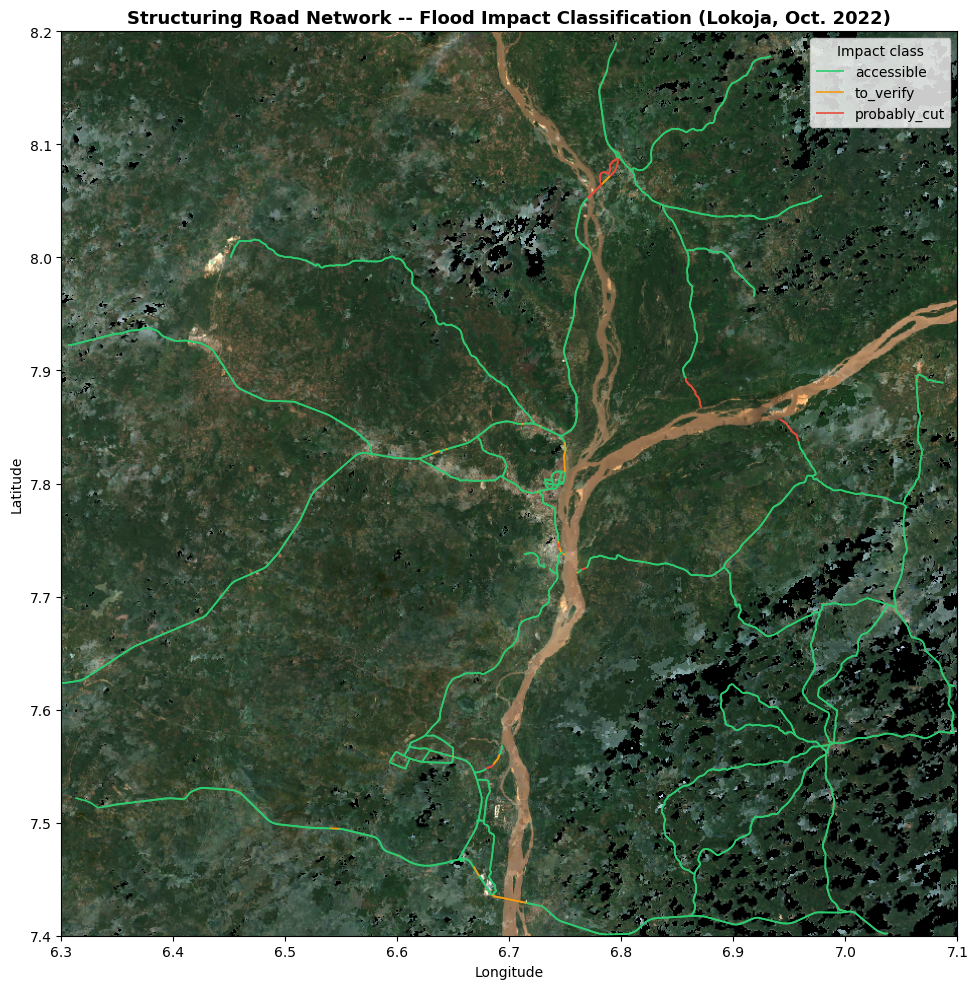

[export] Figure -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Road_Impact_Classification_Map.png


'/Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Road_Impact_Classification_Map.png'

In [16]:
print("Fetching a background composite for the static figure...")
scale = 100
s2_rgb_pre = pre_flood_img.visualize(bands=['B4', 'B3', 'B2'], min=0, max=3000)
arr_bg = geemap.ee_to_numpy(s2_rgb_pre, region=roi, scale=scale)

roads_plot = edges_priority.merge(df_roads[['edge_id', 'impact_class']], on='edge_id', how='inner')

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(arr_bg, extent=[west, east, south, north])
for cls, color in class_colors.items():
    subset = roads_plot[roads_plot['impact_class'] == cls]
    if len(subset):
        subset.plot(ax=ax, color=color, linewidth=1.2, label=cls)
ax.set_xlim(west, east)
ax.set_ylim(south, north)
ax.set_title('Structuring Road Network -- Flood Impact Classification (Lokoja, Oct. 2022)', fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(title='Impact class', loc='upper right')
plt.tight_layout()
plt.show()

save_figure(fig, 'Road_Impact_Classification_Map.png')

## 4.6 Road-network connectivity (optional, §5f)

As an operational read on which localities risk becoming isolated, the segments classified `probably_cut` are removed from the full drivable graph (not just the structuring subset, so that a cut arterial road correctly severs the residential streets that depend on it), and the connected component reachable from central Lokoja is compared before and after removal. The graph is treated as undirected for this first-order estimate — a simplification §7 makes explicit — and Lokoja's town centre stands in for the reference facility (e.g. a hospital) the methodology suggests using.

In [17]:
cut_edge_ids = set(cut_segments['edge_id'])
G_undirected = G_drive.to_undirected()

ref_node = ox.distance.nearest_nodes(G_drive, X=6.73, Y=7.80)  # Lokoja town centre

reachable_before = nx.node_connected_component(G_undirected, ref_node)

G_after = G_undirected.copy()
edges_to_cut = edges.loc[edges['edge_id'].isin(cut_edge_ids), ['u', 'v', 'key']].itertuples(index=False, name=None)
G_after.remove_edges_from([(u, v, k) for u, v, k in edges_to_cut if G_after.has_edge(u, v, k)])

reachable_after = nx.node_connected_component(G_after, ref_node)
isolated_nodes = reachable_before - reachable_after

print(f"Nodes reachable from central Lokoja -- before: {len(reachable_before):,}, after: {len(reachable_after):,}")
print(f"Newly isolated nodes: {len(isolated_nodes):,} "
      f"({len(isolated_nodes) / len(reachable_before) * 100:.1f}% of the previously reachable network)")

Nodes reachable from central Lokoja -- before: 10,936, after: 9,924
Newly isolated nodes: 1,012 (9.3% of the previously reachable network)


In [18]:
isolated_edges = edges[edges['u'].isin(isolated_nodes) & edges['v'].isin(isolated_nodes)]
isolated_km = isolated_edges['length'].sum() / 1000
print(f"Approx. {isolated_km:.1f} km of road lies within the network segment cut off from central Lokoja.")

nodes_gdf = ox.graph_to_gdfs(G_drive, nodes=True, edges=False)
isolated_points = nodes_gdf.loc[list(isolated_nodes), ['y', 'x']].rename(columns={'y': 'lat', 'x': 'lon'})
save_table(isolated_points, 'Isolated_Network_Nodes.csv', index=True)

connectivity_summary = pd.DataFrame({
    'metric': ['Nodes reachable before cut', 'Nodes reachable after cut', 'Newly isolated nodes', 'Isolated road length (km)'],
    'value': [len(reachable_before), len(reachable_after), len(isolated_nodes), round(isolated_km, 1)]
})
display(connectivity_summary)
save_table(connectivity_summary, 'Connectivity_Impact_Summary.csv', index=False)

Approx. 1038.2 km of road lies within the network segment cut off from central Lokoja.
[export] Table  -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Isolated_Network_Nodes.csv


,metric,value
0,Nodes reachable before cut,10936.0
1,Nodes reachable after cut,9924.0
2,Newly isolated nodes,1012.0
3,Isolated road length (km),1038.2


[export] Table  -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Connectivity_Impact_Summary.csv


'/Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Connectivity_Impact_Summary.csv'

# 5. Population Exposure

## 5.1 Population layer

Following §2.2/§5 of the population methodology, WorldPop's 100 m gridded population count is used; the 2020 vintage is the closest available to the October 2022 event (a ~2-year gap made explicit in §7). As the methodology stresses, the fine (10 m) change mask is used to mask the coarser (100 m) population layer, and not the reverse, so that the affected-population footprint keeps the sharper geometry of the flood mask rather than being smoothed to the population grid:

$$\text{Pop}_{\text{affected}} = \sum_{x \,:\, \text{change}(x) = 1} \text{Pop}(x)$$

In [19]:
population = ee.ImageCollection('WorldPop/GP/100m/pop') \
    .filterBounds(roi) \
    .filter(ee.Filter.eq('year', 2020)) \
    .mosaic() \
    .clip(roi)

pop_band = population.bandNames().get(0).getInfo()
print(f"WorldPop band name: {pop_band}")

pop_affected = population.updateMask(change_mask)

WorldPop band name: population


## 5.2 Population affected — sensor comparison

As in the flood-extent comparison in `Index_Analysis.ipynb`, the affected population is reported for the fused mask alongside each sensor individually, so the added value of the S1/S2 union is visible in human terms, not only in hectares.

In [20]:
def get_pop_sum(mask_image, region, scale=100):
    masked = population.updateMask(mask_image)
    stats = masked.reduceRegion(reducer=ee.Reducer.sum(), geometry=region, scale=scale, maxPixels=1e13)
    return stats.getNumber(pop_band).getInfo()

total_zone_pop = population.reduceRegion(
    reducer=ee.Reducer.sum(), geometry=roi, scale=100, maxPixels=1e13
).getNumber(pop_band).getInfo()

pop_s2    = get_pop_sum(flooded_area_mndwi, roi)
pop_s1    = get_pop_sum(s1_flooded_area, roi)
pop_fused = get_pop_sum(change_mask, roi)

pop_comparison = pd.DataFrame({
    'Mask': ['Sentinel-2 (MNDWI)', 'Sentinel-1 (VH)', 'Fused (S1 OR S2)'],
    'Population affected': [round(pop_s2), round(pop_s1), round(pop_fused)],
    '% of ROI population': [round(pop_s2 / total_zone_pop * 100, 2),
                             round(pop_s1 / total_zone_pop * 100, 2),
                             round(pop_fused / total_zone_pop * 100, 2)]
})

print(f"Total WorldPop 2020 population within the ROI: {total_zone_pop:,.0f}")
display(pop_comparison)
save_table(pop_comparison, 'Population_Affected_Comparison.csv', index=False)

Total WorldPop 2020 population within the ROI: 1,083,861


,Mask,Population affected,% of ROI population
0,Sentinel-2 (MNDWI),87586,8.08
1,Sentinel-1 (VH),61934,5.71
2,Fused (S1 OR S2),94375,8.71


[export] Table  -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Population_Affected_Comparison.csv


'/Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Population_Affected_Comparison.csv'

## 5.3 Zonal statistics by administrative unit (§6)

Affected and total population are reduced separately over each Local Government Area (LGA, GAUL level 2) intersecting the ROI, then combined into a single table with the share of each LGA's population inside the flood extent. As in §4.3, `reduceRegions` names its output after the reducer (`'sum'`), not after the population band.

In [21]:
admin = ee.FeatureCollection('FAO/GAUL/2015/level2').filterBounds(roi)

stats_affected = pop_affected.reduceRegions(collection=admin, reducer=ee.Reducer.sum(), scale=100)
stats_total = population.reduceRegions(collection=admin, reducer=ee.Reducer.sum(), scale=100)

def fc_to_pop_df(fc, value_name):
    feats = fc.getInfo()['features']
    rows = [{'ADM2_NAME': f['properties']['ADM2_NAME'],
             'ADM1_NAME': f['properties']['ADM1_NAME'],
             value_name: f['properties'].get('sum')} for f in feats]
    return pd.DataFrame(rows)

df_affected = fc_to_pop_df(stats_affected, 'pop_affected')
df_total = fc_to_pop_df(stats_total, 'pop_total')

admin_pop = df_affected.merge(df_total, on=['ADM2_NAME', 'ADM1_NAME'])
admin_pop['pct_affected'] = (admin_pop['pop_affected'] / admin_pop['pop_total'] * 100).round(2)
admin_pop = admin_pop.sort_values('pop_affected', ascending=False).reset_index(drop=True)
admin_pop[['pop_affected', 'pop_total']] = admin_pop[['pop_affected', 'pop_total']].round(0)

display(admin_pop)
save_table(admin_pop, 'Population_Affected_By_LGA.csv', index=False)

,ADM2_NAME,ADM1_NAME,pop_affected,pop_total,pct_affected
0,Koton-Karfe,Kogi,42827.0,100913.0,42.44
1,Lokoja,Kogi,17345.0,222817.0,7.78
2,Bassa,Kogi,17120.0,136518.0,12.54
3,Ajaokuta,Kogi,10763.0,139140.0,7.74
4,Toto,Nassarawa,3722.0,15725.0,23.67
5,Ofu,Kogi,2319.0,29537.0,7.85
6,Adavi,Kogi,126.0,125453.0,0.10
7,Okehi,Kogi,83.0,84870.0,0.10
8,Okene,Kogi,47.0,104833.0,0.05
9,Kabba /Bunu,Kogi,47.0,26189.0,0.18


[export] Table  -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Population_Affected_By_LGA.csv


'/Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Population_Affected_By_LGA.csv'

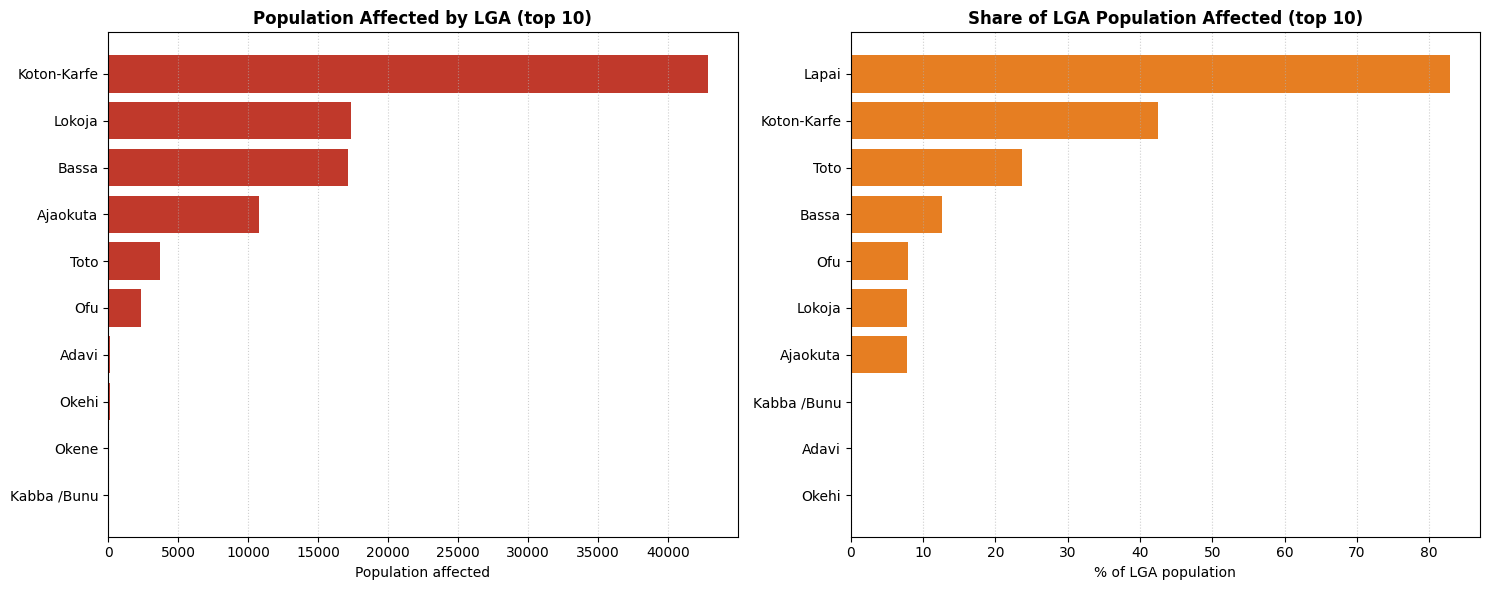

[export] Figure -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Population_Affected_By_LGA.png


'/Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Population_Affected_By_LGA.png'

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

top_n = admin_pop.head(10).iloc[::-1]
axs[0].barh(top_n['ADM2_NAME'], top_n['pop_affected'], color='#c0392b')
axs[0].set_title('Population Affected by LGA (top 10)', fontsize=12, fontweight='bold')
axs[0].set_xlabel('Population affected')

top_pct = admin_pop.sort_values('pct_affected', ascending=False).head(10).iloc[::-1]
axs[1].barh(top_pct['ADM2_NAME'], top_pct['pct_affected'], color='#e67e22')
axs[1].set_title('Share of LGA Population Affected (top 10)', fontsize=12, fontweight='bold')
axs[1].set_xlabel('% of LGA population')

for ax in axs:
    ax.grid(True, linestyle=':', alpha=0.6, axis='x')

plt.tight_layout()
plt.show()

save_figure(fig, 'Population_Affected_By_LGA.png')

## 5.4 Cartography

In [23]:
pop_vis = {'min': 0, 'max': 50, 'palette': ['white', 'gray', 'black']}
Map.addLayer(population, pop_vis, 'WorldPop 2020 (population/ha)', False)
Map.addLayer(pop_affected, {'min': 0, 'max': 50, 'palette': ['yellow', 'red']}, 'Population affected')
Map

Map(center=[7.8, 6.73], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

Fetching population rasters for the static figure...


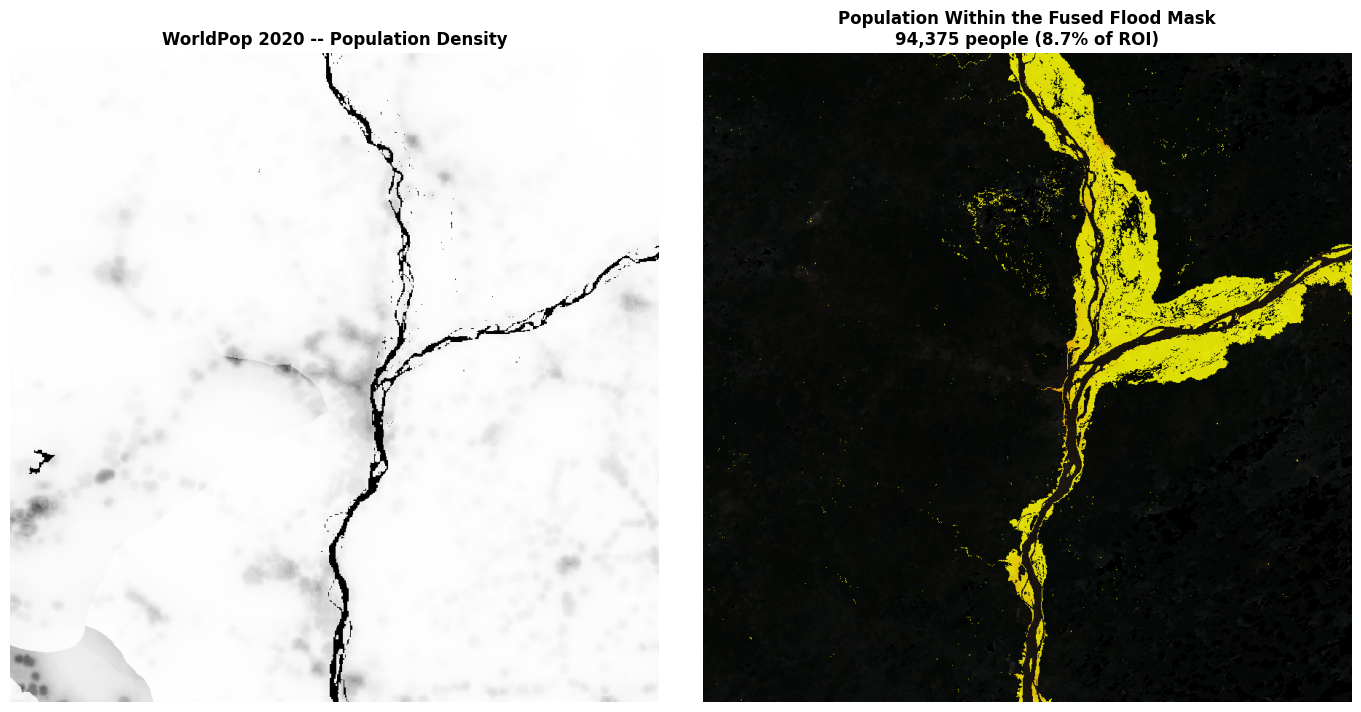

[export] Figure -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Population_Exposure_Map.png


'/Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Population_Exposure_Map.png'

In [24]:
print("Fetching population rasters for the static figure...")
arr_pop = geemap.ee_to_numpy(population.visualize(**pop_vis), region=roi, scale=100)
arr_pop_affected = geemap.ee_to_numpy(
    pop_affected.visualize(min=0, max=50, palette=['yellow', 'red']), region=roi, scale=100
)

fig, axs = plt.subplots(1, 2, figsize=(14, 7))
axs[0].imshow(arr_pop)
axs[0].set_title('WorldPop 2020 -- Population Density', fontsize=12, fontweight='bold')
axs[0].axis('off')

axs[1].imshow(arr_bg)  # reuse the pre-flood background composite fetched in §4.5
axs[1].imshow(arr_pop_affected, alpha=0.85)
axs[1].set_title(f'Population Within the Fused Flood Mask\n{pop_fused:,.0f} people '
                  f'({pop_fused/total_zone_pop*100:.1f}% of ROI)', fontsize=12, fontweight='bold')
axs[1].axis('off')

plt.tight_layout()
plt.show()

save_figure(fig, 'Population_Exposure_Map.png')

# 6. Cross-Cutting Synthesis: Population Near the Isolated Road Network

Sections 4.6 and 5 can be combined into a single, more operational question raised in §1.3 of the road methodology: how many people live in the part of the network cut off from central Lokoja? As a first-order proxy — not a true travel-time or service-area model — a 500 m buffer is drawn around every node found isolated in §4.6, and the population inside that buffer is summed. This should be read as an order of magnitude, not a precise count: see §7 for the caveats that apply.

In [25]:
if len(isolated_nodes) > 0:
    coords = isolated_points[['lon', 'lat']].values.tolist()
    isolated_buffer = ee.Geometry.MultiPoint(coords).buffer(500)

    pop_isolated = population.reduceRegion(
        reducer=ee.Reducer.sum(), geometry=isolated_buffer, scale=100, maxPixels=1e13
    ).getNumber(pop_band).getInfo()

    print(f"Approx. {pop_isolated:,.0f} people live within 500 m of a road node cut off from central Lokoja "
          f"({pop_isolated / total_zone_pop * 100:.1f}% of the ROI population).")

    synthesis = pd.DataFrame({
        'metric': ['Isolated network nodes', 'Isolated road length (km)', 'Population near isolated network (500 m buffer)'],
        'value': [len(isolated_nodes), round(isolated_km, 1), round(pop_isolated)]
    })
else:
    print("No segment was classified 'probably_cut', so no node was newly isolated.")
    synthesis = pd.DataFrame({
        'metric': ['Isolated network nodes', 'Isolated road length (km)', 'Population near isolated network (500 m buffer)'],
        'value': [0, 0.0, 0]
    })

display(synthesis)
save_table(synthesis, 'Synthesis_Isolated_Population.csv', index=False)

Approx. 29,423 people live within 500 m of a road node cut off from central Lokoja (2.7% of the ROI population).


,metric,value
0,Isolated network nodes,1012.0
1,Isolated road length (km),1038.2
2,Population near isolated network (500 m buffer),29423.0


[export] Table  -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Synthesis_Isolated_Population.csv


'/Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Synthesis_Isolated_Population.csv'

# 7. Validation and Limitations

**External validation.** For an event of this scale, the fused mask and the resulting road/population impact figures should be cross-checked against the Copernicus Emergency Management Service (Rapid Mapping) products issued for the 2022 Nigeria floods, OCHA/UNOSAT situation reports, and any Humanitarian OpenStreetMap Team (HOT) mapping activation for the area — all three are the reference sources both methodologies point to (§6 of the road methodology, §7 of the population methodology). A visual check against very-high-resolution imagery on a sample of the segments flagged `probably_cut` is the cheapest sanity check available before these figures are shared operationally.

**Limitations to carry forward with these results:**
- *Population vintage.* WorldPop's 2020 layer is roughly two years older than the October 2022 event — the population methodology (§2.2) flags this explicitly. Population growth and any settlement change in Kogi State between 2020 and 2022 are not captured.
- *OSM completeness.* Road density in OSM is uneven outside the built-up core of Lokoja; a `to_verify` or `accessible` classification on a sparsely-mapped rural segment may reflect missing OSM geometry rather than an actually-unaffected road, and the network used for §4.6's connectivity read inherits the same gaps.
- *Sensor resolution and geometry.* At 10 m, sub-pixel damage (a washed-out culvert, a cracked carriageway with no surface-water signature) is invisible to this method; it captures large inundated segments, not point failures. SAR shadow/layover in areas of relief, and any residual orbit-geometry mismatch despite the fix applied in §3, can also produce false positives along road embankments.
- *Threshold transfer.* The 0.5 / 0.15 impact-fraction thresholds and the −19 dB / MNDWI > 0 water thresholds are the ones calibrated and statistically validated for this ROI in `Index_Analysis.ipynb`; they are not universal and should be recalibrated for another site or hazard.
- *Connectivity analysis is a simplification.* §4.6 treats the road graph as undirected and uses Lokoja's town centre, not a real facility, as the reference point; §6's 500 m buffer around isolated nodes is an order-of-magnitude proxy for "population cut off," not a travel-time or service-area model. Both should be read as a first pass motivating field verification, not as a routing-grade result.

# 8. Summary of Exported Outputs

Verification listing of every figure and table exported to the shared `outputs` folder by either notebook — `Index_Analysis.ipynb`'s flood-detection outputs and this notebook's road/population impact outputs live side by side.

In [26]:
exported_files = sorted(os.listdir(OUT_DIR))
print(f"Contents of {OUT_DIR}:\n")
for fname in exported_files:
    fpath = os.path.join(OUT_DIR, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {fname:55s} {size_kb:10.1f} KB")

Contents of /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs:

  Comprehensive_Index_Distributions_All_Indices.png            574.7 KB
  Connectivity_Impact_Summary.csv                                0.1 KB
  Cross_Index_Correlation_Heatmap.png                          223.3 KB
  Cross_Index_Correlation_Matrix.csv                             0.2 KB
  Flood_Comparison_Summary_Lokoja.png                        29040.7 KB
  Flood_Extent_Comparison_Ha.csv                                 0.2 KB
  H1_Observation_Probability_And_S1_Complementarity.png        452.3 KB
  Isolated_Network_Nodes.csv                                    31.1 KB
  Monthly_Climatology_Clear_Fraction.csv                         0.2 KB
  Monthly_Climatology_Observability.png                        165.6 KB
  Monthly_Exploitable_Observation_Probability.csv                0.3 KB
  Population_Affected_By_LGA.csv                                 0.5 KB
  Population_Affected_By_LGA.png    